In [20]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
from tobii_pytracker.analyze.data_loader import DataLoader
from tobii_pytracker.configs.custom_config import CustomConfig

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from tobii_pytracker.analyze.models import (
    HeatmapAnalyzer,
    FocusMapAnalyzer,
    FixationAnalyzer,
    SaccadeAnalyzer,
    EntropyAnalyzer,
    ClusterAnalyzer,
    ConceptAnalyzer,
    ScanpathsAnalyzer,
    VoiceTranscription,
    BBoxAttentionAnalyzer
)


config = CustomConfig('../configs/config.yaml')
loader = DataLoader(config, root='../')

▶ Global heatmap statistics


,avg_gaze_x,avg_gaze_y,gaze_count
0,-48.940127,41.07097,1218


▶ Per-set statistics


,set_name,avg_gaze_x,avg_gaze_y,gaze_count
0,20260712_201106,-73.558450,52.570201,596
1,20260712_215741,-33.359387,46.160940,339
2,20260712_221650,-15.757619,10.756336,283


▶ Per-slide statistics


,set_name,slide_index,avg_gaze_x,avg_gaze_y,gaze_count
0,20260712_201106,0,0.496672,126.178458,54
1,20260712_201106,1,-136.970846,86.770293,41
2,20260712_201106,2,-119.749876,110.488777,63
3,20260712_201106,3,-56.953125,51.798718,53
4,20260712_201106,4,-42.326600,18.074442,105


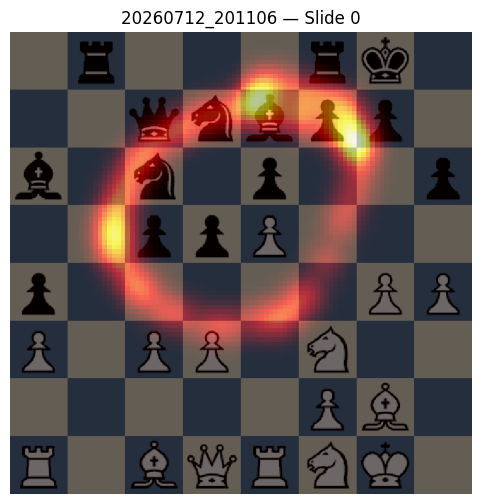

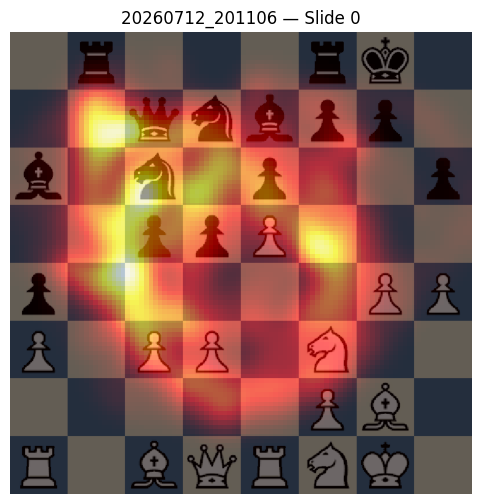

In [22]:
# Assuming you already have the data
background_data = pd.concat(loader.get_all_data(flatten=True).values(), ignore_index=True)
output_dir = Path("./analysis_outputs")

analyzer = HeatmapAnalyzer(output_folder=output_dir)

# --- Global ---
print("▶ Global heatmap statistics")
global_stats = analyzer.analyze(background_data, per="global")
display(global_stats)

# --- Set-level ---
print("▶ Per-set statistics")
set_stats = analyzer.analyze(background_data, per="set")
display(set_stats.head())

# --- Slide-level ---
print("▶ Per-slide statistics")
slide_stats = analyzer.analyze(background_data, per="slide")
display(slide_stats.head())

# --- Plot heatmap for one image ---
example_slide = background_data.iloc[0]
subset = background_data[
    (background_data["set_name"] == example_slide["set_name"]) &
    (background_data["slide_index"] == example_slide["slide_index"])
]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

analyzer.plot_analysis(
    background_data=subset,
    screenshot_path=screenshot_path,
    title=f"{example_slide['set_name']} — Slide {example_slide['slide_index']}",
)


analyzer.plot_analysis(
    background_data=background_data,
    screenshot_path=screenshot_path,
    title=f"{example_slide['set_name']} — Slide {example_slide['slide_index']}",
)


▶ Global focus map statistics


,avg_gaze_x,avg_gaze_y,gaze_count
0,-48.940127,41.07097,1218


▶ Per-set statistics


,set_name,avg_gaze_x,avg_gaze_y,gaze_count
0,20260712_201106,-73.558450,52.570201,596
1,20260712_215741,-33.359387,46.160940,339
2,20260712_221650,-15.757619,10.756336,283


▶ Per-slide statistics


,set_name,slide_index,avg_gaze_x,avg_gaze_y,gaze_count
0,20260712_201106,0,0.496672,126.178458,54
1,20260712_201106,1,-136.970846,86.770293,41
2,20260712_201106,2,-119.749876,110.488777,63
3,20260712_201106,3,-56.953125,51.798718,53
4,20260712_201106,4,-42.326600,18.074442,105


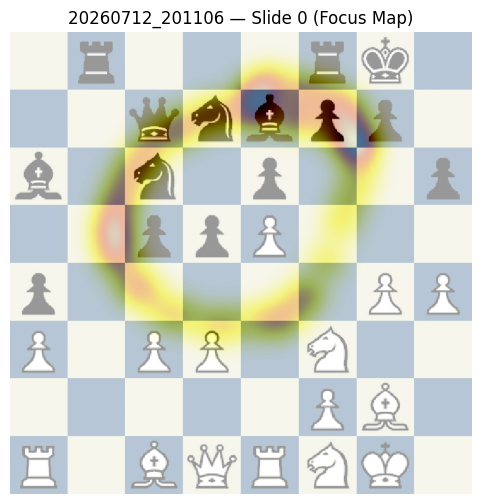

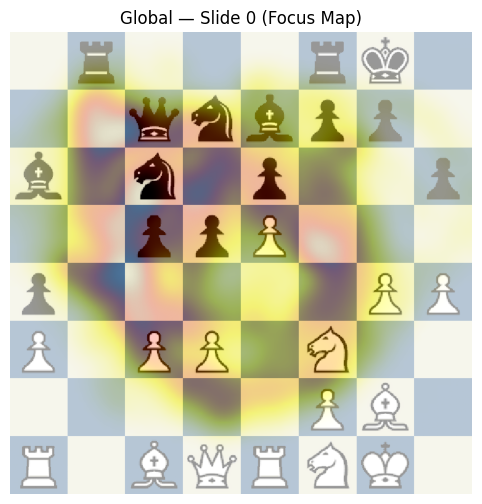

In [23]:
# --- Prepare background data ---
background_data = pd.concat(loader.get_all_data(flatten=True).values(), ignore_index=True)
output_dir = Path("./analysis_outputs")

analyzer = FocusMapAnalyzer(output_folder=output_dir)

# --- Global ---
print("▶ Global focus map statistics")
global_stats = analyzer.analyze(background_data, per="global")
display(global_stats)

# --- Set-level ---
print("▶ Per-set statistics")
set_stats = analyzer.analyze(background_data, per="set")
display(set_stats.head())

# --- Slide-level ---
print("▶ Per-slide statistics")
slide_stats = analyzer.analyze(background_data, per="slide")
display(slide_stats.head())

# ============================================================
# 🖼 Plot focus map for one example slide
# ============================================================

example_slide = background_data.iloc[0]
subset = background_data[
    (background_data["set_name"] == example_slide["set_name"]) &
    (background_data["slide_index"] == example_slide["slide_index"])
]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

# --- Focus map for single slide (individual subject) ---
analyzer.plot_analysis(
    background_data=subset,
    screenshot_path=screenshot_path,
    title=f"{example_slide['set_name']} — Slide {example_slide['slide_index']} (Focus Map)",
)

# --- Focus map using all gaze data for this slide (across subjects) ---
analyzer.plot_analysis(
    background_data=background_data,
    screenshot_path=screenshot_path,
    title=f"Global — Slide {example_slide['slide_index']} (Focus Map)",
)

▶ Detecting saccades...


,set_name,slide_index,start_time,end_time,duration,x_start,y_start,x_end,y_end,amplitude,peak_velocity,mean_velocity,mean_acceleration
0,20260712_201106,0,24.076338,25.089039,1.033287,180.335938,201.679688,16.097656,260.117188,174.324853,4547.681049,1411.082877,35677.049701
1,20260712_201106,1,30.670398,30.670398,0.020742,-186.292969,208.664062,-186.984375,208.664062,0.691406,33.333099,33.333099,10237.456407
2,20260712_201106,1,30.711734,31.415082,0.724024,-189.949219,207.335938,-245.160156,214.386719,55.659331,4231.421946,1497.438531,33243.295828
3,20260712_201106,2,37.311041,38.370047,1.079624,-166.210938,227.386719,-240.464844,256.140625,79.626815,2428.790229,1218.113843,22052.797135
4,20260712_201106,3,46.628529,47.630307,1.022472,-112.355469,201.062500,-195.468750,24.867188,194.814285,3633.812877,1542.605384,28687.055401


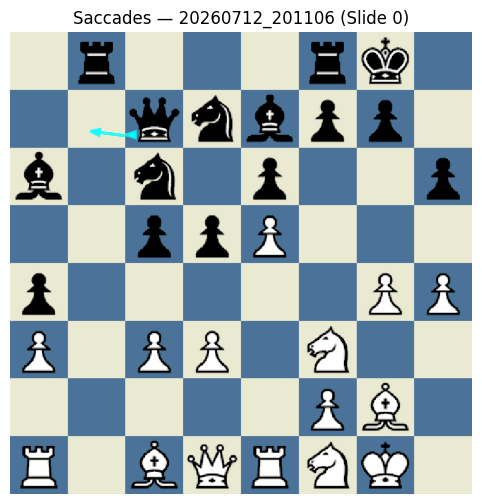

In [24]:
background_data = pd.concat(loader.get_all_data(flatten=True).values(), ignore_index=True)
output_dir = Path("./analysis_outputs")

saccade_analyzer = SaccadeAnalyzer(
    output_folder=output_dir,
    method="ivt",               # "ivt" (velocity-based) or "acceleration"
    velocity_threshold=120.0,   # pixels/sec
    acceleration_threshold=6000.0,  # pixels/sec^2
    min_duration=0.015,         # seconds
)

print("▶ Detecting saccades...")
saccades = saccade_analyzer.analyze(background_data)
display(saccades.head())

example_slide = background_data.iloc[0]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

saccade_analyzer.plot_analysis(
    saccades=saccades,
    screenshot_path=screenshot_path,
    set_name=example_slide["set_name"],
    slide_index=int(example_slide["slide_index"]) + 1,
    title=f"Saccades — {example_slide['set_name']} (Slide {example_slide['slide_index']})",
)

▶ Detecting fixations...


,fix_start,fix_end,duration,x_mean,y_mean,dispersion,set_name,slide_index
0,30.628896,30.753075,0.124179,-196.689732,201.482143,60.027344,20260712_201106,1
1,31.332533,31.435692,0.103159,-240.699870,217.049479,31.878906,20260712_201106,1
2,37.269763,37.393723,0.123959,-185.434152,224.215960,66.914062,20260712_201106,2
3,38.214562,38.328224,0.113662,-213.324777,266.208705,65.773438,20260712_201106,2
4,38.348852,38.514489,0.165637,-241.410156,253.061198,14.339844,20260712_201106,2


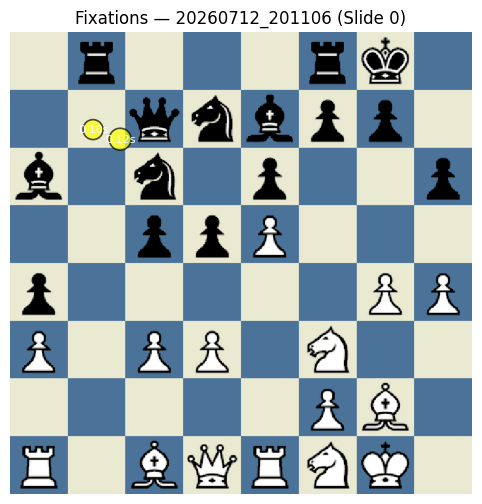

In [25]:
background_data = pd.concat(loader.get_all_data(flatten=True).values(), ignore_index=True)
output_dir = Path("./analysis_outputs")

fixation_analyzer = FixationAnalyzer(
    output_folder=output_dir,
    method="dispersion",           # or "velocity"
    dispersion_threshold=60.0,     # pixels
    min_duration=0.08,             # seconds
)

print("▶ Detecting fixations...")
fixations = fixation_analyzer.analyze(background_data)
display(fixations.head())

example_slide = background_data.iloc[0]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

fixation_analyzer.plot_analysis(
    fixations=fixations,
    screenshot_path=screenshot_path,
    set_name=example_slide["set_name"],
    slide_index=int(example_slide["slide_index"]) + 1,
    title=f"Fixations — {example_slide['set_name']} (Slide {example_slide['slide_index']})",
)

▶ Performing gaze clustering...


,set_name,slide_index,screenshot_file,input_data,classification,user_classification,model_prediction,voice_file,voice_start_timestamp,event_type,...,gaze_x_left,gaze_y_left,gaze_x_right,gaze_y_right,pupil_left,pupil_right,avg_gaze_x,avg_gaze_y,avg_pupil_size,cluster
0,20260712_201106,0,output/20260712_201106/frame_34_delay-1s.gif,datasets/chess/good/frame_34_delay-1s.gif,good,good,None,NaN,NaN,MonocularEyeSampleEventNT,...,194.183594,192.035156,None,None,5,0,194.183594,192.035156,2.5,0
1,20260712_201106,0,output/20260712_201106/frame_34_delay-1s.gif,datasets/chess/good/frame_34_delay-1s.gif,good,good,None,NaN,NaN,MonocularEyeSampleEventNT,...,180.335938,201.679688,None,None,5,0,180.335938,201.679688,2.5,0
2,20260712_201106,0,output/20260712_201106/frame_34_delay-1s.gif,datasets/chess/good/frame_34_delay-1s.gif,good,good,None,NaN,NaN,MonocularEyeSampleEventNT,...,169.066406,209.187500,None,None,5,0,169.066406,209.187500,2.5,0
3,20260712_201106,0,output/20260712_201106/frame_34_delay-1s.gif,datasets/chess/good/frame_34_delay-1s.gif,good,good,None,NaN,NaN,MonocularEyeSampleEventNT,...,140.296875,221.882812,None,None,5,0,140.296875,221.882812,2.5,0
4,20260712_201106,0,output/20260712_201106/frame_34_delay-1s.gif,datasets/chess/good/frame_34_delay-1s.gif,good,good,None,NaN,NaN,MonocularEyeSampleEventNT,...,104.863281,233.472656,None,None,5,0,104.863281,233.472656,2.5,-1


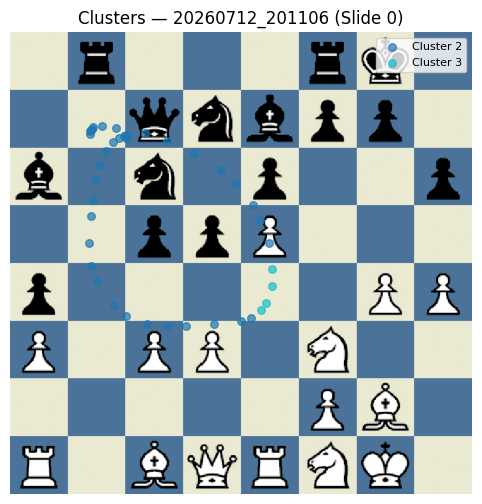

In [26]:
# ==============================================
# 👁️ Cluster Analyzer Demo
# ==============================================
from pathlib import Path
import pandas as pd

background_data= pd.concat(loader.get_all_data(flatten=True).values(), ignore_index=True)
output_dir = Path("./analysis_outputs")

# Instantiate analyzer (DBSCAN by default)
cluster_analyzer = ClusterAnalyzer(
    output_folder=output_dir,
    eps=20,              # pixel distance for clustering
    min_samples=3,        # minimum points per cluster
)

print("▶ Performing gaze clustering...")
clustered_data = cluster_analyzer.analyze(background_data)
display(clustered_data.head())

# --- Visualization for one slide ---
example_slide = background_data.iloc[0]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

cluster_analyzer.plot_analysis(
    background_data=clustered_data,
    screenshot_path=screenshot_path,
    set_name=example_slide["set_name"],
    slide_index=int(example_slide["slide_index"]) + 1,
    title=f"Clusters — {example_slide['set_name']} (Slide {example_slide['slide_index']})",
)

▶ Slide-level entropy


,entropy,convex_hull_area,num_points,set_name,slide_index
0,5.754888,113816.371544,54,20260712_201106,0
1,5.308772,75842.237625,41,20260712_201106,1
2,5.743075,118544.655876,63,20260712_201106,2
3,5.727920,141673.909378,53,20260712_201106,3
4,6.426011,149693.160469,105,20260712_201106,4


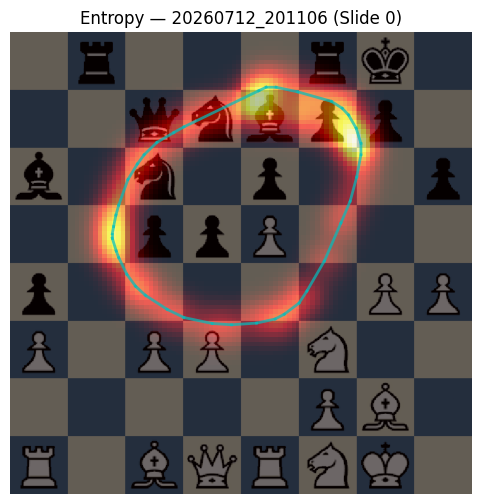

In [27]:
# ==============================================
# 🧠 Entropy Analyzer Demo
# ==============================================
background_data = pd.concat(loader.get_all_data(flatten=True).values(), ignore_index=True)
output_dir = Path("./analysis_outputs")

entropy_analyzer = EntropyAnalyzer(output_folder=output_dir)

print("▶ Slide-level entropy")
entropy_results = entropy_analyzer.analyze(background_data, per="slide", bins=100, use_convex_hull=True)
display(entropy_results.head())

# --- Visualization for one example slide ---
example_slide = background_data.iloc[0]
subset = background_data[
    (background_data["set_name"] == example_slide["set_name"]) &
    (background_data["slide_index"] == example_slide["slide_index"])
]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

entropy_analyzer.plot_analysis(
    background_data=subset,
    screenshot_path=screenshot_path,
    title=f"Entropy — {example_slide['set_name']} (Slide {example_slide['slide_index']})",
)


▶ Loading raw and flattened experiment data
Raw rows: 30
Gaze rows: 1218


,set_name,screenshot_file,input_data,classification,user_classification,gaze_data,objects_bboxes,voice_file,voice_start_timestamp,slide_index
0,20260712_201106,output/20260712_201106/frame_34_delay-1s.gif,datasets/chess/good/frame_34_delay-1s.gif,good,good,"[{'event_type': 'MonocularEyeSampleEventNT', '...","{'image_bboxes': [{'class': 'superpixel', 'con...",NaN,NaN,0
1,20260712_201106,output/20260712_201106/frame_09_delay-1s.gif,datasets/chess/good/frame_09_delay-1s.gif,good,bad,"[{'event_type': 'MonocularEyeSampleEventNT', '...","{'image_bboxes': [{'class': 'superpixel', 'con...",NaN,NaN,1
2,20260712_201106,output/20260712_201106/frame_39_delay-1s.gif,datasets/chess/good/frame_39_delay-1s.gif,good,bad,"[{'event_type': 'MonocularEyeSampleEventNT', '...","{'image_bboxes': [{'class': 'superpixel', 'con...",NaN,NaN,2
3,20260712_201106,output/20260712_201106/frame_36_delay-1s.gif,datasets/chess/good/frame_36_delay-1s.gif,good,none,"[{'event_type': 'MonocularEyeSampleEventNT', '...","{'image_bboxes': [{'class': 'superpixel', 'con...",NaN,NaN,3
4,20260712_201106,output/20260712_201106/frame_64_delay-3s.gif,datasets/chess/bad/frame_64_delay-3s.gif,bad,bad,"[{'event_type': 'MonocularEyeSampleEventNT', '...","{'image_bboxes': [{'class': 'superpixel', 'con...",NaN,NaN,4


,set_name,slide_index,screenshot_file,input_data,classification,user_classification,model_prediction,voice_file,voice_start_timestamp,event_type,...,system_time,gaze_x_left,gaze_y_left,gaze_x_right,gaze_y_right,pupil_left,pupil_right,avg_gaze_x,avg_gaze_y,avg_pupil_size
0,20260712_201106,0,output/20260712_201106/frame_34_delay-1s.gif,datasets/chess/good/frame_34_delay-1s.gif,good,good,None,NaN,NaN,MonocularEyeSampleEventNT,...,24.035081,194.183594,192.035156,None,None,5,0,194.183594,192.035156,2.5
1,20260712_201106,0,output/20260712_201106/frame_34_delay-1s.gif,datasets/chess/good/frame_34_delay-1s.gif,good,good,None,NaN,NaN,MonocularEyeSampleEventNT,...,24.055752,180.335938,201.679688,None,None,5,0,180.335938,201.679688,2.5
2,20260712_201106,0,output/20260712_201106/frame_34_delay-1s.gif,datasets/chess/good/frame_34_delay-1s.gif,good,good,None,NaN,NaN,MonocularEyeSampleEventNT,...,24.076338,169.066406,209.187500,None,None,5,0,169.066406,209.187500,2.5
3,20260712_201106,0,output/20260712_201106/frame_34_delay-1s.gif,datasets/chess/good/frame_34_delay-1s.gif,good,good,None,NaN,NaN,MonocularEyeSampleEventNT,...,24.097060,140.296875,221.882812,None,None,5,0,140.296875,221.882812,2.5
4,20260712_201106,0,output/20260712_201106/frame_34_delay-1s.gif,datasets/chess/good/frame_34_delay-1s.gif,good,good,None,NaN,NaN,MonocularEyeSampleEventNT,...,24.117772,104.863281,233.472656,None,None,5,0,104.863281,233.472656,2.5


▶ Mapping gaze points to generated bboxes


,set_name,slide_index,screenshot_file,input_data,bbox_index,bbox_class,bbox_conf,cx,cy,w,h,total_gaze_points,hit_count,coverage,dwell_time,attention_score,attention_rank
0,20260712_201106,0,output/20260712_201106/frame_34_delay-1s.gif,datasets/chess/good/frame_34_delay-1s.gif,0,superpixel,1.0,-281.250,328.125,187.50,93.75,54,0,0.000000,0.0,0.000000,8
1,20260712_201106,0,output/20260712_201106/frame_34_delay-1s.gif,datasets/chess/good/frame_34_delay-1s.gif,1,superpixel,1.0,-140.625,281.250,93.75,187.50,54,2,0.037037,2.0,0.037037,6
2,20260712_201106,0,output/20260712_201106/frame_34_delay-1s.gif,datasets/chess/good/frame_34_delay-1s.gif,2,superpixel,1.0,-46.875,281.250,93.75,187.50,54,4,0.074074,4.0,0.074074,4
3,20260712_201106,0,output/20260712_201106/frame_34_delay-1s.gif,datasets/chess/good/frame_34_delay-1s.gif,3,superpixel,1.0,140.625,234.375,281.25,281.25,54,23,0.425926,23.0,0.425926,1
4,20260712_201106,0,output/20260712_201106/frame_34_delay-1s.gif,datasets/chess/good/frame_34_delay-1s.gif,4,superpixel,1.0,328.125,328.125,93.75,93.75,54,0,0.000000,0.0,0.000000,8


Generated bbox score rows: 1154
▶ Evaluating bbox/gaze mapping quality


,set_name,slide_index,bbox_count,attended_bboxes,attended_bbox_ratio,total_gaze_points,bbox_hit_count,coverage_by_bboxes,max_attention_score,mean_attention_score
1,20260712_201106,1,37,14,0.378378,41,68,1.658537,0.414634,0.044825
9,20260712_201106,9,36,10,0.277778,71,116,1.633803,0.619718,0.045383
2,20260712_201106,2,38,14,0.368421,63,98,1.555556,0.444444,0.040936
11,20260712_215741,1,32,14,0.437500,35,54,1.542857,0.342857,0.048214
5,20260712_201106,5,35,10,0.285714,60,87,1.450000,0.533333,0.041429
24,20260712_221650,4,36,9,0.250000,36,52,1.444444,0.361111,0.040123
15,20260712_215741,5,35,19,0.542857,48,69,1.437500,0.375000,0.041071
26,20260712_221650,6,37,9,0.243243,23,32,1.391304,0.304348,0.037603
3,20260712_201106,3,36,12,0.333333,53,71,1.339623,0.452830,0.037212
21,20260712_221650,1,40,11,0.275000,30,40,1.333333,0.233333,0.033333


▶ Visualizing attended bboxes on screenshot


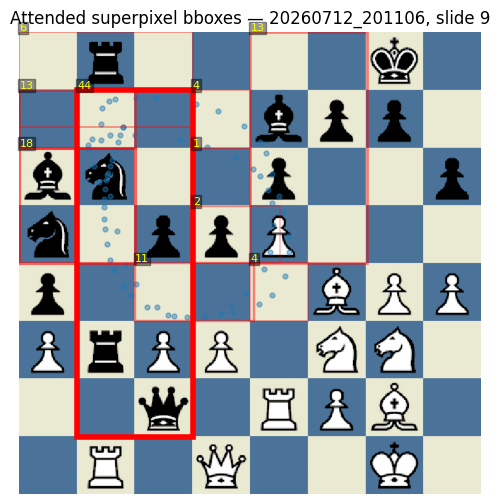

,set_name,slide_index,bbox_count,attended_bboxes,attended_bbox_ratio,total_gaze_points,bbox_hit_count,coverage_by_bboxes,max_attention_score,mean_attention_score
0,20260712_201106,0,38,0,0.000000,0,0,0.000000,0.00,0.000000
1,20260712_201106,1,37,2,0.054054,2,3,1.500000,1.00,0.040541
2,20260712_201106,2,38,2,0.052632,3,5,1.666667,1.00,0.043860
3,20260712_201106,3,36,2,0.055556,1,2,2.000000,1.00,0.055556
4,20260712_201106,4,43,6,0.139535,8,9,1.125000,0.25,0.026163


In [28]:
from pathlib import Path
import pandas as pd

print("▶ Loading raw and flattened experiment data")

raw_data = pd.concat(
    loader.get_all_data(flatten=False).values(),
    keys=loader.get_all_data(flatten=False).keys(),
    names=["set_name", "row_index"],
).reset_index(level="set_name")

raw_data = raw_data.reset_index(drop=True)

# Make slide_index explicit and consistent with DataLoader flattening
raw_data["slide_index"] = raw_data.groupby("set_name").cumcount()

gaze_data = pd.concat(
    loader.get_all_data(flatten=True).values(),
    ignore_index=True,
)

print("Raw rows:", len(raw_data))
print("Gaze rows:", len(gaze_data))

display(raw_data.head())
display(gaze_data.head())


output_dir = Path("./analysis_outputs")

bbox_analyzer = BBoxAttentionAnalyzer(output_folder=output_dir)

print("▶ Mapping gaze points to generated bboxes")

bbox_scores = bbox_analyzer.analyze(
    raw_data=raw_data,
    gaze_data=gaze_data,
    use_fixations=False,
)

display(bbox_scores.head())
print("Generated bbox score rows:", len(bbox_scores))

print("▶ Evaluating bbox/gaze mapping quality")

bbox_eval = bbox_analyzer.evaluate(bbox_scores)

display(bbox_eval.sort_values(
    ["coverage_by_bboxes", "attended_bbox_ratio"],
    ascending=False,
).head(20))

print("▶ Visualizing attended bboxes on screenshot")

# Select a slide that actually has gaze hits and bboxes
example = (
    bbox_scores[bbox_scores["hit_count"] > 0]
    .sort_values("attention_score", ascending=False)
    .iloc[0]
)

set_name = example["set_name"]
slide_index = int(example["slide_index"])

example_slide = raw_data[
    (raw_data["set_name"].astype(str) == str(set_name))
    & (raw_data["slide_index"].astype(int) == slide_index)
].iloc[0]

screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

bbox_analyzer.plot_analysis(
    scored_bboxes=bbox_scores,
    gaze_data=gaze_data,
    screenshot_path=screenshot_path,
    set_name=set_name,
    slide_index=slide_index,
    top_k=25,
    min_hits=1,
    title=f"Attended superpixel bboxes — {set_name}, slide {slide_index}",
    save_path=output_dir / f"bbox_attention_{set_name}_slide_{slide_index}.png",
)

fixations = fixation_analyzer.analyze(background_data)


bbox_fixation_scores = bbox_analyzer.analyze(
    raw_data=raw_data,
    gaze_data=fixations.rename(columns={
        "x_mean": "x_mean",
        "y_mean": "y_mean",
    }),
    use_fixations=True,
)

bbox_fixation_eval = bbox_analyzer.evaluate(bbox_fixation_scores)

display(bbox_fixation_eval.head())